# Matching

The goal is to do two sets of Matching.

- **Intent to Treat Matching**: Match those who were admitted to the program (Non-Graduates AND Graduates) and match them against those who did NOT attend the Program (Interviewed and Non-TIP)
- **Treatment Matching**: Match those who graduated from the program against those that did not graduate from the program.

We will Match to determine:
- TIP's affect on Income Earnings
- TIP's affect on Employment
- TIP's affect on Criminal Justice Interactions
- TIP's affect on Recidivism

In [114]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm

In [115]:
tip_clean = pd.read_csv('TIP_Clean.csv', parse_dates = ['CreatedDate', 'DoB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date'])

In [116]:
all_tip_students = tip_clean.rename(columns={
    'participant_id': 'tip_id',
    'DoB': 'DOB', 
    'Status': 'tip_status',
})

In [117]:
# define status
def status(row):
    ts = str(row['tip_status'])
    if "Graduate" in ts:
        return 'Graduated'
    elif ("DNF" in ts) and ("Orientation" not in ts):
        return 'Non Graduated'
    else:
        return 'None'

all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
None             1281
Graduated         893
Non Graduated     549
Name: count, dtype: int64

In [118]:
all_tip_students.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Status'],
      dtype='object')

In [119]:
# Load data
df_student = all_tip_students.copy()

date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors='coerce')

# pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    np.nan
)
df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors="coerce")


# Demographics
tip_demo = pd.read_csv('tip_cohort_demographics_rg.csv')[['tip_id', 'gender', 'race', 'census_tract']]
tip_demo['tip_id'] = pd.to_numeric(tip_demo['tip_id'], errors='coerce')

df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demo,
    on='tip_id',
    how='left'
)

# Age at start + age band
df_student['age_at_start'] = np.where(
    df_student['StartDate'].notna() & df_student['DOB'].notna(),
    (df_student['StartDate'] - df_student['DOB']).dt.days // 365,
    np.nan
)

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['age_at_start'].apply(assign_age_band)

# Sentencing data
tip_sentencing = pd.read_csv(
    'convictions_matched_to_tip_final.csv',
    parse_dates=['DOB', 'DOS', 'StartDate']
)

tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

In [120]:
# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

# Arrest data
tip_arrests = pd.read_csv(
    'arrest_data.csv',
    parse_dates=['ArrestDate', 'StartDate']
)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()


In [121]:
# Earnings data
tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')
df_inflation = pd.read_csv('inflation_data.csv')

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to fiscal quarter end month/day
# Q1 -> 12/31 (same year)
# Q2 -> 03/31 (next year)
# Q3 -> 06/30 (next year)
# Q4 -> 09/30 (next year)
month_map = {1: 12, 2: 3, 3: 6, 4: 9}
day_map   = {1: 31, 2: 31, 3: 30, 4: 30}

tip_earnings["fiscal_end_year"] = tip_earnings["year"]
tip_earnings["fiscal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["fiscal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["fiscal_end_year"],
        month=tip_earnings["fiscal_end_month"],
        day=tip_earnings["fiscal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "fiscal_end_year", "fiscal_end_month", "fiscal_end_day"], errors="ignore", inplace=True)

# adjust income data for inflation
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

df_earnings = tip_earnings.copy()
df_earnings["year_month"] = df_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
df_earnings["CPI"] = df_earnings["year_month"].map(cpi_map)

df_earnings["earnings"] = df_earnings["earnings"] * (latest_cpi / df_earnings["CPI"])

df_earnings['tip_id'] = pd.to_numeric(df_earnings['tip_id'], errors='coerce')
df_earnings['quarter'] = df_earnings['quarter'].astype(str)

df_earnings['year'] = pd.to_numeric(df_earnings['quarter'].str[:4], errors='coerce')
df_earnings['q_num'] = pd.to_numeric(df_earnings['quarter'].str[-1], errors='coerce')

quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df_earnings['quarter_label'] = df_earnings['q_num'].replace(quarter_map)

df_earnings['year_quarter'] = (
    df_earnings['year'].astype('Int64').astype(str) + '-' + df_earnings['quarter_label']
)
df_earnings['year_quarter_dt'] = pd.PeriodIndex(
    df_earnings['year_quarter'],
    freq='Q'
).to_timestamp()

df_earnings = df_earnings.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left'
)

df_earnings['age'] = (
    (df_earnings['year_quarter_dt'] - df_earnings['DOB']).dt.days // 365
)

# keep non-missing earnings, but DO NOT drop zeros
df_earnings = df_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
df_earnings['quarters_from_start'] = (
    (df_earnings['year_quarter_dt'].dt.year - df_earnings['StartDate'].dt.year) * 4
    + (df_earnings['year_quarter_dt'].dt.quarter - df_earnings['StartDate'].dt.quarter)
)

# Helper function to calculate annualized earnings based on available quarters
def calculate_annualized_earnings(group):
    # We calculate the mean of observed quarters and multiply by 4
    # This assumes missing quarters are missing at random, not necessarily zero
    return group.mean() * 4

# 1. Earnings one year prior: quarters -4 to -1
# Logic: Average the available quarters in this window and multiply by 4
earnings_1yr_prior = df_earnings[
    df_earnings['quarters_from_start'].between(-4, -1)
].groupby('tip_id')['earnings'].agg(calculate_annualized_earnings).reset_index(name='earnings_year_prior')

# 2. Earnings two years prior: quarters -8 to -1
# Logic: We calculate the average quarterly earning across the 8-quarter window and multiply by 4 for an "annual" rate
# Note: If you want the TOTAL 2-year sum, multiply by 8, but usually "2yr prior" refers to an annual average
earnings_2yr_prior = df_earnings[
    df_earnings['quarters_from_start'].between(-8, -1)
].groupby('tip_id')['earnings'].agg(calculate_annualized_earnings).reset_index(name='earnings_two_years_prior')

# 3. Employment right before TIP: any positive earnings in quarter -1
# (This remains the same as it checks for existence, not a sum/average)
job_right_before = df_earnings[
    df_earnings['quarters_from_start'] == -1
].groupby('tip_id')['earnings'].apply(lambda x: 1 if (x > 0).any() else 0).reset_index(name='job_right_before_tip')

C:\Users\13429\AppData\Local\Temp\ipykernel_6380\2010919959.py:2: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')


In [122]:
# Build TIP baseline summary table
tip_base = df_student.copy()

tip_base = tip_base.merge(sent_summary, on='tip_id', how='left')
tip_base = tip_base.merge(arrest_summary, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_1yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_2yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(job_right_before, on='tip_id', how='left')

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in tip_base.columns:
        tip_base[col] = tip_base[col].fillna(0)

print("tip_base shape:", tip_base.shape)
print("\nTIP missingness summary:")
print(
    tip_base[
        [
            'tip_id', 'DOB', 'StartDate', 'Status', 'cohort_2022',
            'age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_year_prior', 'earnings_two_years_prior',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

tip_base shape: (2723, 43)

TIP missingness summary:
tip_id                          0
DOB                            75
StartDate                     888
Status                          0
cohort_2022                   888
age_at_start                  919
age_band                      929
gender                        533
race                          546
census_tract                  546
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_year_prior             0
earnings_two_years_prior        0
job_right_before_tip            0
dtype: int64


## Graduate vs. Non-Graduate Analysis File

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.  
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assemble baseline covariates measured before TIP start, and create post-TIP outcome variables.

We define:

- **Treatment group**: Graduated participants
- **Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

- \(Y_e\): any employment
- \(Y_w\): total earnings
- \(Y_o\): any offense
- \(Y_a\): any arrest
- \(Y_c\): any post-TIP conviction-related offense record

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment.

In [123]:
# 1. Start from the cleaned TIP baseline table
grad_non_grad = tip_base.copy()

# Keep only Graduated and Non Graduated participants
grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

# Apply the study cutoff used in the original notebook
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2024-06-01')
].copy()

# Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

# Keep plausible adult ages
grad_non_grad = grad_non_grad[
    grad_non_grad['age_at_start'].notna() &
    (grad_non_grad['age_at_start'] > 15)
].copy()

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

# Optional: if census_tract is numeric, convert non-missing values to int-like string
grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [124]:
# 2. Build post-TIP timing variables

# Sentencing years since TIP
tip_sentencing_analysis = tip_sentencing.copy()
tip_sentencing_analysis = tip_sentencing_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_sentencing_analysis.columns:
    tip_sentencing_analysis['StartDate'] = tip_sentencing_analysis['StartDate_base'].combine_first(
        tip_sentencing_analysis['StartDate']
    )
    tip_sentencing_analysis = tip_sentencing_analysis.drop(columns=['StartDate_base'])

tip_sentencing_analysis['YearsSinceTIP'] = (
    (tip_sentencing_analysis['DOS'] - tip_sentencing_analysis['StartDate']).dt.days / 365.25
)

# Arrest years since TIP
tip_arrests_analysis = tip_arrests.copy()
tip_arrests_analysis = tip_arrests_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_arrests_analysis.columns:
    tip_arrests_analysis['StartDate'] = tip_arrests_analysis['StartDate_base'].combine_first(
        tip_arrests_analysis['StartDate']
    )
    tip_arrests_analysis = tip_arrests_analysis.drop(columns=['StartDate_base'])

tip_arrests_analysis['YearsSinceTIP'] = (
    (tip_arrests_analysis['ArrestDate'] - tip_arrests_analysis['StartDate']).dt.days / 365.25
)

# Earnings years since TIP
tip_earnings_analysis = df_earnings.copy()

if 'StartDate' not in tip_earnings_analysis.columns:
    tip_earnings_analysis = tip_earnings_analysis.merge(
        tip_base[['tip_id', 'StartDate']].drop_duplicates(),
        on='tip_id',
        how='left'
    )

tip_earnings_analysis['YearsSinceTIP'] = (
    (tip_earnings_analysis['year_quarter_dt'] - tip_earnings_analysis['StartDate']).dt.days / 365.25
)

In [125]:
# 3. Construct post-TIP outcomes within 1.5 years

# Employment outcome: any positive earnings within 1.5 years after TIP start
# --- REVISED EMPLOYMENT OUTCOME LOGIC (1.5 YEAR WINDOW) ---

# Define the 1.5 year post-TIP window
post_tip_15yr = tip_earnings_analysis[
    (tip_earnings_analysis['YearsSinceTIP'] > 0) & 
    (tip_earnings_analysis['YearsSinceTIP'] <= 1.5)
].copy()

# Group by tip_id to calculate the metrics
employment_outcome = (
    post_tip_15yr.groupby('tip_id')['earnings']
    .agg(
        # 1. employment_outcome: 1 if they had ANY positive earnings in this 1.5yr window, else 0
        employment_outcome=lambda x: 1 if (x > 0).any() else 0,
        
        # 2. employment_outcome_earnings: Average of available quarters * 6 (for 1.5 years)
        # Note: .mean() automatically ignores NaNs
        employment_outcome_earnings=lambda x: x.mean() * 6
    )
    .reset_index()
)
employment_outcome['employment_outcome_earnings'] = employment_outcome['employment_outcome_earnings'].fillna(0)

# Offense outcome: any sentencing record within 1.5 years after TIP start
offense_outcome = (
    tip_sentencing_analysis[
        (tip_sentencing_analysis['YearsSinceTIP'] > 0) &
        (tip_sentencing_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='offense_count_post_1_5y')
)

offense_outcome['offense_outcome'] = 1

# Arrest outcome: any arrest within 1.5 years after TIP start
arrest_outcome = (
    tip_arrests_analysis[
        (tip_arrests_analysis['YearsSinceTIP'] > 0) &
        (tip_arrests_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='arrest_count_post_1_5y')
)

arrest_outcome['arrest_outcome'] = 1

In [126]:
# 4. Merge outcomes into analysis file
grad_non_grad = grad_non_grad.merge(
    employment_outcome,
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    offense_outcome[['tip_id', 'offense_outcome', 'offense_count_post_1_5y']],
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    arrest_outcome[['tip_id', 'arrest_outcome', 'arrest_count_post_1_5y']],
    on='tip_id',
    how='left'
)

grad_non_grad.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,treatment,employment_outcome,employment_outcome_earnings,offense_outcome,offense_count_post_1_5y,arrest_outcome,arrest_count_post_1_5y
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.000000,274.696002,0.0,0,1.0,35231.806855,NaN,NaN,NaN,NaN
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,25842.060029,17001.449453,1.0,0,1.0,4316.801168,NaN,NaN,NaN,NaN
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.000000,0.000000,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,0.000000,0.000000,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,0.000000,0.000000,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
# Fill outcome missings with 0
outcome_fill_zero_cols = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'offense_count_post_1_5y',
    'arrest_outcome',
    'arrest_count_post_1_5y'
]

for col in outcome_fill_zero_cols:
    if col in grad_non_grad.columns:
        grad_non_grad[col] = grad_non_grad[col].fillna(0)

# Ensure binary outcomes are integer
binary_cols = ['employment_outcome', 'offense_outcome', 'arrest_outcome']
for col in binary_cols:
    grad_non_grad[col] = grad_non_grad[col].astype(int)

# Add TIP start year
grad_non_grad['year_TIP'] = grad_non_grad['StartDate'].dt.year

# Final column order for this section
grad_non_grad = grad_non_grad[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'DOB',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
    ]
].copy()

print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'employment_outcome_earnings',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1154, 27)

Status counts:
Status
Graduated        720
Non Graduated    434
Name: count, dtype: int64

Treatment counts:
treatment
1    720
0    434
Name: count, dtype: int64

Cohort counts:
cohort_2022
1.0    852
2.0    302
Name: count, dtype: int64

Age band counts:
age_band
25-34    501
<=24     450
35+      197
NaN        6
Name: count, dtype: int64

Outcome means:
employment_outcome                 0.610052
employment_outcome_earnings    10198.629716
offense_outcome                    0.124783
arrest_outcome                     0.110052
dtype: float64


In [128]:
grad_non_grad.columns

Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP', 'cohort_2022',
       'DOB', 'age_at_start', 'age_band', 'race', 'gender', 'census_tract',
       'any_sentence_before_start', 'num_sentences_before_start',
       'max_ogs_before_start', 'any_high_ogs_before_start',
       'any_arrest_before_start', 'num_arrests_before_start',
       'earnings_year_prior', 'earnings_two_years_prior',
       'job_right_before_tip', 'employment_outcome',
       'employment_outcome_earnings', 'offense_outcome',
       'offense_count_post_1_5y', 'arrest_outcome', 'arrest_count_post_1_5y'],
      dtype='object')

## Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort**, **race**, **gender**, and **age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [129]:
# 1. Prepare covariates for diagnostic models

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'any_arrest_before_start',
        'job_right_before_tip',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1154, 16)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'any_sentence_before_start', 'any_arrest_before_start', 'job_right_before_tip', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior', 'cohort_2022_2', 'age_band_35+', 'age_band_<=24', 'age_band_Unknown', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [130]:
# 2. Check multicollinearity

# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

,VIF
gender_Unknown,12.981590
race_Unknown,12.876217
gender_Male,4.669356
any_sentence_before_start,3.204234
any_arrest_before_start,2.813424
cohort_2022_2,2.730168
treatment,2.462835
year_TIP,2.453435
job_right_before_tip,2.329991
num_arrests_before_start,1.873155


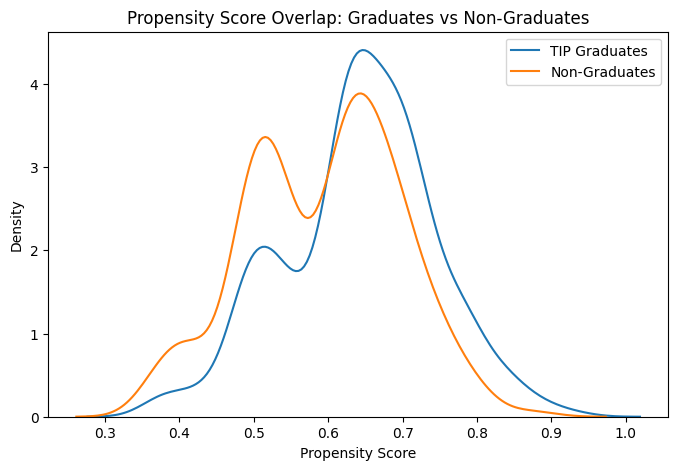


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          434.0  0.594162  0.102551  0.352889  0.516816  0.613352  0.667609   
1          720.0  0.641865  0.101828  0.358588  0.580184  0.648803  0.706044   

                max  
treatment            
0          0.881785  
1          0.937075  


In [131]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [132]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()

         Current function value: 0.392681
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1154
Model:                          Logit   Df Residuals:                     1137
Method:                           MLE   Df Model:                           16
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.4128
Time:                        17:09:55   Log-Likelihood:                -453.15
converged:                      False   LL-Null:                       -771.71
Covariance Type:            nonrobust   LLR p-value:                3.040e-125
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.6346      0.356      1.780      0.075      -0.064       1.333
treatment                      0.2558      0.177      1.443      0.149      -0.092       0.603
year_TIP                       1.7641      0.166     10.606      0.000       1.438       2.090
any_sentence_before_start      0.1072      0.233      0.461      0.645      -0.349       0.563
any_arrest_before_start        0.3552      0.264      1.347      0.178      -0.162       0.872
job_right_before_tip           1.7957      0.318      5.644      0.000       1.172       2.419
num_sentences_before_start    -0.2249      0.110     -2.047      0.041      -0.440      -0.010
num_arrests_before_start       0.0241      0.106      0.228      0.819      -0.183       0.231
earnings_two_years_prior       0.4072      0.212      1.919      0.055      -0.009       0.823
cohort_2022_2                 -2.7001      0.335     -8.059      0.000      -3.357      -2.043
age_band_35+                  -0.0628      0.229     -0.275      0.784      -0.511       0.385
age_band_<=24                  0.1487      0.191      0.780      0.435      -0.225       0.522
age_band_Unknown               0.0034      1.215      0.003      0.998      -2.378       2.385
race_Unknown                 -18.9175   4573.268     -0.004      0.997   -8982.358    8944.523
race_White                    -0.0424      0.263     -0.161      0.872      -0.559       0.474
gender_Male                    0.1936      0.297      0.652      0.514      -0.388       0.775
gender_Unknown                -5.5738   1.96e+04     -0.000      1.000   -3.83e+04    3.83e+04
==============================================================================================
"""

In [133]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   0.634618  7.502053e-02
1                    treatment   0.255822  1.488947e-01
2                     year_TIP   1.764107  2.784354e-26
3    any_sentence_before_start   0.107157  6.450583e-01
4      any_arrest_before_start   0.355222  1.780819e-01
5         job_right_before_tip   1.795719  1.658948e-08
6   num_sentences_before_start  -0.224904  4.067136e-02
7     num_arrests_before_start   0.024124  8.193174e-01
8     earnings_two_years_prior   0.407244  5.493847e-02
9                cohort_2022_2  -2.700075  7.668597e-16
10                age_band_35+  -0.062816  7.835897e-01
11               age_band_<=24   0.148672  4.353709e-01
12            age_band_Unknown   0.003372  9.977861e-01
13                race_Unknown -18.917508  9.966995e-01
14                  race_White  -0.042418  8.720274e-01
15                 gender_Male   0.193566  5.141527e-01
16              gender_Unknown  -5.573757  9.997

The current naive employment model is:

$$
\text{logit}(p_e) =
\beta_0 + \beta_1(\text{treatment}) + \beta_2(\text{year\_TIP}) +
\beta_3(\text{any\_sentence\_before\_start}) +
\\beta_4(\text{any\_arrest\_before\_start}) +
\beta_5(\text{job\_right\_before\_tip}) +
\beta_6(\text{num\_sentences\_before\_start}) +
\\beta_7(\text{num\_arrests\_before\_start}) +
\beta_8(\text{earnings\_two\_years\_prior}) + \gamma'Z
$$

where \(Z\) includes indicator variables for:

- cohort\_2022
- age band
- race
- gender

This model is descriptive and is used only as a preliminary diagnostic before formal matching. The propensity score model in this section uses the same pre-TIP covariates and demographic variables, excluding treatment itself, to evaluate overlap between graduates and non-graduates.

## Matching

In [134]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
        
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['treatment', 'cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['treatment'] = matching_df['treatment'].astype(int)
matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

matching_df shape: (1148, 26)

Treatment counts:
treatment
1    716
0    432
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022     race   gender age_band  treatment    n
0             1    Black   Female    25-34          0    5
1             1    Black   Female    25-34          1   11
2             1    Black   Female      35+          0    4
3             1    Black   Female      35+          1    5
4             1    Black   Female     <=24          0   10
5             1    Black   Female     <=24          1   11
6             1    Black     Male    25-34          0  116
7             1    Black     Male    25-34          1  195
8             1    Black     Male      35+          0   35
9             1    Black     Male      35+          1   86
10            1    Black     Male     <=24          0  121
11            1    Black     Male     <=24          1  107
12            1  Unknown     Male    25-34          0    1
13            1  Unknown     Male    25-34 

In [135]:
psm_df = matching_df.copy()

# Covariates for propensity score model
# psm_covariates = psm_df[
    # [
        # 'year_TIP',
        # 'any_sentence_before_start',
        # 'num_sentences_before_start',
        # 'max_ogs_before_start',
        # 'any_high_ogs_before_start',
        # 'any_arrest_before_start',
        # 'num_arrests_before_start',
        # 'earnings_year_prior',
        # 'earnings_two_years_prior',
        # 'job_right_before_tip',
        # 'conviction_record_count_y'
    # ]
# ].copy()

psm_covariates = psm_df[
    [
        'year_TIP',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'any_high_ogs_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Standardize continuous variables
continuous_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior'
]

scaler = StandardScaler()
psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

# Fit logistic regression for propensity score
psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, psm_df['treatment'])

psm_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

print(psm_df['pscore'].describe())

print("\nPropensity score by treatment:")
print(psm_df.groupby('treatment')['pscore'].describe())

count    1148.000000
mean        0.623692
std         0.060302
min         0.469941
25%         0.581093
50%         0.622055
75%         0.666703
max         0.930111
Name: pscore, dtype: float64

Propensity score by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          432.0  0.613877  0.058128  0.484621  0.566732  0.617143  0.657210   
1          716.0  0.629613  0.060854  0.469941  0.585415  0.628450  0.669937   

                max  
treatment            
0          0.759902  
1          0.930111  


In [136]:
def nearest_neighbor_match_within_strata(
    df,
    exact_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement
    within exact-match strata, using propensity score distance.

    caliper is applied on the absolute difference in propensity score.
    """
    matched_rows = []
    matched_control_ids = set()

    treated_df = df[df[treatment_col] == 1].copy()
    control_df = df[df[treatment_col] == 0].copy()

    treated_df = treated_df.sort_values(pscore_col).reset_index(drop=True)

    pair_id = 1

    for _, treated_row in treated_df.iterrows():
        strata_mask = np.ones(len(control_df), dtype=bool)

        for var in exact_vars:
            strata_mask &= (control_df[var] == treated_row[var])

        eligible_controls = control_df.loc[strata_mask].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls = eligible_controls[
            ~eligible_controls[id_col].isin(matched_control_ids)
        ].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls['pscore_diff'] = np.abs(
            eligible_controls[pscore_col] - treated_row[pscore_col]
        )

        eligible_controls = eligible_controls[
            eligible_controls['pscore_diff'] <= caliper
        ].copy()

        if len(eligible_controls) == 0:
            continue

        best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

        treated_out = treated_row.to_dict()
        treated_out['match_pair_id'] = pair_id
        treated_out['match_role'] = 'treated'
        treated_out['matched_to_id'] = best_control[id_col]
        treated_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        control_out = best_control.to_dict()
        control_out['match_pair_id'] = pair_id
        control_out['match_role'] = 'control'
        control_out['matched_to_id'] = treated_row[id_col]
        control_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        matched_rows.append(treated_out)
        matched_rows.append(control_out)

        matched_control_ids.add(best_control[id_col])
        pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender', 'age_band']

matched_grad_non_grad = nearest_neighbor_match_within_strata(
    df=psm_df,
    exact_vars=exact_match_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

matched_grad_non_grad shape: (830, 32)

Matched pair count: 415

Matched treatment counts:
treatment
1    415
0    415
Name: count, dtype: int64


In [137]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        415
Non Graduated    415
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             1    Black   Female    25-34          0    5
1             1    Black   Female    25-34          1    5
2             1    Black   Female      35+          0    4
3             1    Black   Female      35+          1    4
4             1    Black   Female     <=24          0   10
5             1    Black   Female     <=24          1   10
6             1    Black     Male    25-34          0  116
7             1    Black     Male    25-34          1  116
8             1    Black     Male      35+          0   35
9             1    Black     Male      35+          1   35
10            1    Black     Male     <=24          0  107
11            1    Black     Male     <=24          1  107
12            1  Unknown     Male    25-34          0    1
13            1  Unknown     Male    25-34     

In [138]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)

,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,606,0.469941,1,Black,Male,35+,0.018611,851,0.488552
1,2,576,0.472006,1,Black,Male,25-34,0.012615,702,0.484621
2,3,886,0.483378,1,Black,Male,25-34,0.003190,843,0.486568
3,4,797,0.490207,1,Black,Male,35+,0.011543,1044,0.501750
4,5,709,0.491381,1,Black,Male,<=24,0.003614,687,0.487767
5,6,789,0.493007,1,Black,Male,25-34,0.004909,739,0.488098
6,7,757,0.496468,1,Black,Male,25-34,0.005989,742,0.502457
7,8,812,0.497311,1,Black,Male,25-34,0.021765,833,0.519076
8,9,967,0.498223,1,Black,Male,<=24,0.002669,868,0.500892
9,10,659,0.500788,1,Black,Male,35+,0.012814,1145,0.513601


In [139]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()

Final matched analysis file shape: (830, 32)


,tip_id,Status,treatment,StartDate,year_TIP,cohort_2022,age_at_start,age_band,race,gender,...,offense_outcome,offense_count_post_1_5y,arrest_outcome,arrest_count_post_1_5y,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,851,Non Graduated,0,2018-10-08,2018,1,39.0,35+,Black,Male,...,0,0.0,0,0.0,0.488552,1,control,606,0.018611,0.018611
1,606,Graduated,1,2017-07-05,2017,1,40.0,35+,Black,Male,...,0,0.0,0,0.0,0.469941,1,treated,851,0.018611,NaN
2,702,Non Graduated,0,2018-01-15,2018,1,32.0,25-34,Black,Male,...,0,0.0,0,0.0,0.484621,2,control,576,0.012615,0.012615
3,576,Graduated,1,2017-05-01,2017,1,34.0,25-34,Black,Male,...,0,0.0,0,0.0,0.472006,2,treated,702,0.012615,NaN
4,843,Non Graduated,0,2018-10-01,2018,1,26.0,25-34,Black,Male,...,0,0.0,0,0.0,0.486568,3,control,886,0.003190,0.003190


## Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.

In [140]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))

Matched sample size: 830
Matched pair count: 415

Treatment counts:
treatment
0    415
1    415
Name: count, dtype: int64

Status counts:
Status
Non Graduated    415
Graduated        415
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1  All
cohort_2022               
1            328  328  656
2             87   87  174
All          415  415  830

Age band by treatment:
treatment    0    1  All
age_band                
25-34      169  169  338
35+         53   53  106
<=24       193  193  386
All        415  415  830

Race by treatment:
treatment    0    1  All
race                    
Black      351  351  702
Unknown     25   25   50
White       39   39   78
All        415  415  830

Gender by treatment:
treatment    0    1  All
gender                  
Female      35   35   70
Male       356  356  712
Unknown     24   24   48
All        415  415  830


In [141]:
matched_analysis.columns

Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP', 'cohort_2022',
       'age_at_start', 'age_band', 'race', 'gender', 'census_tract',
       'any_sentence_before_start', 'num_sentences_before_start',
       'max_ogs_before_start', 'any_high_ogs_before_start',
       'any_arrest_before_start', 'num_arrests_before_start',
       'earnings_year_prior', 'earnings_two_years_prior',
       'job_right_before_tip', 'employment_outcome',
       'employment_outcome_earnings', 'offense_outcome',
       'offense_count_post_1_5y', 'arrest_outcome', 'arrest_count_post_1_5y',
       'pscore', 'match_pair_id', 'match_role', 'matched_to_id',
       'match_pscore_diff', 'pscore_diff'],
      dtype='object')

In [142]:
balance_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
    
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.354217,2017.718072,-0.636145
num_sentences_before_start,2.074699,1.727711,-0.346988
max_ogs_before_start,2.621687,2.330120,-0.291566
any_high_ogs_before_start,0.255422,0.231325,-0.024096
num_arrests_before_start,1.195181,1.007229,-0.187952
earnings_year_prior,3849.754032,3743.074452,-106.679579
earnings_two_years_prior,3664.626604,3504.358106,-160.268498
job_right_before_tip,0.313253,0.373494,0.060241


In [143]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
0,year_TIP,-0.177319
7,job_right_before_tip,0.126970
1,num_sentences_before_start,-0.096206
2,max_ogs_before_start,-0.080135
4,num_arrests_before_start,-0.065488
3,any_high_ogs_before_start,-0.056108
6,earnings_two_years_prior,-0.024426
5,earnings_year_prior,-0.014877


Matched pair propensity-score difference summary:
count    415.000000
mean       0.031850
std        0.034310
min        0.000000
25%        0.004393
50%        0.023927
75%        0.043925
max        0.189089
Name: match_pscore_diff, dtype: float64


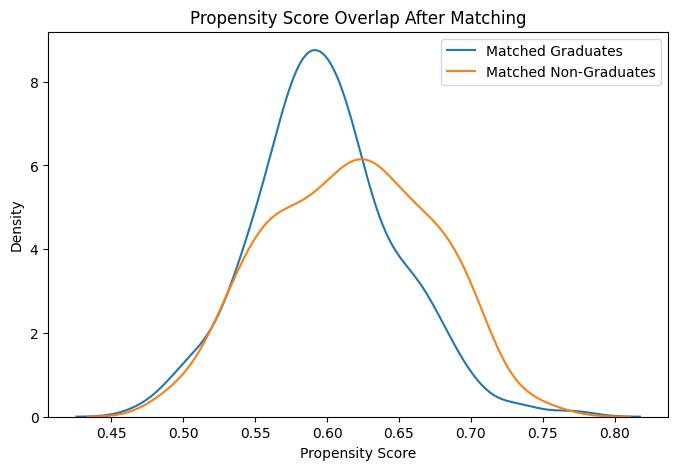

In [144]:
print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()

In [145]:
outcome_vars = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.604819,0.585542,-0.019277
employment_outcome_earnings,9242.290403,8602.373243,-639.917160
offense_outcome,0.134940,0.125301,-0.009639
arrest_outcome,0.108434,0.096386,-0.012048


Overall, the matched sample appears usable for downstream analysis. Most standardized mean differences are below 0.10, indicating reasonably good balance after matching. A few justice-history variables remain somewhat imbalanced, especially:

- number of sentences before TIP start
- maximum OGS before TIP start
- any sentence before TIP start

Their absolute SMDs are still above 0.10, although they remain below 0.20. This suggests that the matching procedure substantially improved comparability, but did not fully eliminate all baseline differences in prior justice involvement. As a result, these variables should still be included as controls in the next matched regression models.

The preliminary matched outcome comparisons show a consistent pattern. Relative to matched non-graduates, matched graduates have:

- a higher employment rate within 1.5 years after TIP start
- higher post-TIP earnings
- a lower offense rate
- a slightly lower arrest rate

In substantive terms, the matched descriptive results suggest that graduation from TIP is associated with better labor-market outcomes and somewhat better justice-related outcomes. However, these are still descriptive comparisons within the matched sample. The next step is to estimate regression models on the matched sample, with additional adjustment for the remaining baseline imbalances, to test whether these differences remain after covariate adjustment.

## Matched Regression Analysis

After checking balance and outcome differences in the matched sample, the next step is to estimate regression models on the matched data.

These models serve two purposes. First, they test whether the observed differences between graduates and non-graduates remain after further adjustment for the baseline variables that still show some residual imbalance after matching. Second, they provide a more formal estimate of the association between TIP graduation and post-TIP outcomes within the matched sample.

The matched regressions use the matched graduate vs. non-graduate sample and cluster standard errors by matched pair. We estimate four models:

- a logistic regression for employment within 1.5 years after TIP start
- an OLS regression for post-TIP earnings within 1.5 years
- a logistic regression for offense within 1.5 years
- a logistic regression for arrest within 1.5 years

These matched regressions are more informative than simple matched mean comparisons because they adjust for remaining baseline differences, especially in prior sentencing severity and prior justice involvement.

In [146]:
matched_reg_df = matched_grad_non_grad.copy()

# Keep only variables needed for regression
matched_reg_df = matched_reg_df[
    [
        'tip_id',
        'match_pair_id',
        'match_role',
        'treatment',
        'Status',
        'year_TIP',
        'cohort_2022',
        'age_band',
        'race',
        'gender',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'arrest_outcome'
    ]
].copy()

# Keep a numeric version of cohort_2022 for checking / reference
matched_reg_df['cohort_2022'] = pd.to_numeric(matched_reg_df['cohort_2022'], errors='coerce')

# Clean categorical variables for regression
matched_reg_df['cohort_2022_str'] = matched_reg_df['cohort_2022'].astype('Int64').astype(str)
matched_reg_df['age_band'] = matched_reg_df['age_band'].fillna('Unknown').astype(str)
matched_reg_df['race'] = matched_reg_df['race'].fillna('Unknown').astype(str)
matched_reg_df['gender'] = matched_reg_df['gender'].fillna('Unknown').astype(str)

print("matched_reg_df shape:", matched_reg_df.shape)
print("\nMatched pairs:", matched_reg_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_reg_df['treatment'].value_counts(dropna=False))
print("\nCohort counts:")
print(matched_reg_df['cohort_2022'].value_counts(dropna=False))

matched_reg_df shape: (830, 24)

Matched pairs: 415

Treatment counts:
treatment
0    415
1    415
Name: count, dtype: int64

Cohort counts:
cohort_2022
1    656
2    174
Name: count, dtype: int64


In [147]:
# Core baseline controls
X_base = matched_reg_df[
    [
        'treatment',
        'year_TIP'
        
    ]
].copy()

# Add categorical controls
X_cat = pd.get_dummies(
    matched_reg_df[['cohort_2022_str']],
    drop_first=True,
    dtype=int
)

# Build design matrix
X_matched = pd.concat([X_base, X_cat], axis=1)

# Create treatment × cohort_2022 interaction
# After get_dummies(drop_first=True), the post-2022 cohort dummy will usually be cohort_2022_str_2
if 'cohort_2022_str_2' in X_matched.columns:
    X_matched['treatment_x_cohort_2022_2'] = (
        X_matched['treatment'] * X_matched['cohort_2022_str_2']
    )
else:
    raise ValueError("Expected dummy column 'cohort_2022_str_2' was not found in X_matched.")

X_matched = sm.add_constant(X_matched)

print("Design matrix shape:", X_matched.shape)
print("\nColumns:")
print(X_matched.columns.tolist())

Design matrix shape: (830, 5)

Columns:
['const', 'treatment', 'year_TIP', 'cohort_2022_str_2', 'treatment_x_cohort_2022_2']


In [148]:
Y_employment = matched_reg_df['employment_outcome'].astype(int)

employment_model = sm.Logit(Y_employment, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

employment_model.summary()

Optimization terminated successfully.
         Current function value: 0.461525
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                  830
Model:                          Logit   Df Residuals:                      825
Method:                           MLE   Df Model:                            4
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.3162
Time:                        17:09:57   Log-Likelihood:                -383.07
converged:                       True   LL-Null:                       -560.18
Covariance Type:              cluster   LLR p-value:                 2.140e-75
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                     -1294.0853    103.649    -12.485      0.000   -1497.234   -1090.937
treatment                     0.2640      0.187      1.411      0.158      -0.103       0.631
year_TIP                      0.6417      0.051     12.483      0.000       0.541       0.742
cohort_2022_str_2            -2.8756      0.428     -6.713      0.000      -3.715      -2.036
treatment_x_cohort_2022_2     0.5986      0.382      1.567      0.117      -0.150       1.347
=============================================================================================
"""

In [149]:
Y_earnings = matched_reg_df['employment_outcome_earnings'].astype(float)

earnings_model = sm.OLS(Y_earnings, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

earnings_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     employment_outcome_earnings   R-squared:                       0.105
Model:                                     OLS   Adj. R-squared:                  0.100
Method:                          Least Squares   F-statistic:                     40.64
Date:                         Sat, 28 Mar 2026   Prob (F-statistic):           9.99e-29
Time:                                 17:09:57   Log-Likelihood:                -8997.9
No. Observations:                          830   AIC:                         1.801e+04
Df Residuals:                              825   BIC:                         1.803e+04
Df Model:                                    4                                         
Covariance Type:                       cluster                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                     -2.992e+06   2.72e+05    -11.008      0.000   -3.52e+06   -2.46e+06
treatment                  -105.5766    973.230     -0.108      0.914   -2013.071    1801.918
year_TIP                   1487.6162    134.855     11.031      0.000    1223.306    1751.927
cohort_2022_str_2         -6401.6920   1887.672     -3.391      0.001   -1.01e+04   -2701.924
treatment_x_cohort_2022_2  1965.2797   2092.656      0.939      0.348   -2136.250    6066.809
==============================================================================
Omnibus:                      295.986   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              847.352
Skew:                           1.819   Prob(JB):                    1.00e-184
Kurtosis:                       6.358   Cond. No.                     1.54e+06
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 1.54e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [150]:
earnings_summary = earnings_model.summary2().tables[1].reset_index()
print(earnings_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                       index         Coef.       Std.Err.         P>|z|
0                      const -2.991952e+06  271807.534851  3.511852e-28
1                  treatment -1.055766e+02     973.229584  9.136144e-01
2                   year_TIP  1.487616e+03     134.854670  2.700705e-28
3          cohort_2022_str_2 -6.401692e+03    1887.671572  6.955769e-04
4  treatment_x_cohort_2022_2  1.965280e+03    2092.655574  3.476630e-01


In [151]:
Y_offense = matched_reg_df['offense_outcome'].astype(int)

offense_model = sm.Logit(Y_offense, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

offense_model.summary()

Optimization terminated successfully.
         Current function value: 0.384374
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        offense_outcome   No. Observations:                  830
Model:                          Logit   Df Residuals:                      825
Method:                           MLE   Df Model:                            4
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                0.005798
Time:                        17:09:57   Log-Likelihood:                -319.03
converged:                       True   LL-Null:                       -320.89
Covariance Type:              cluster   LLR p-value:                    0.4450
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       107.2693     70.180      1.528      0.126     -30.281     244.820
treatment                    -0.1446      0.224     -0.645      0.519      -0.584       0.295
year_TIP                     -0.0541      0.035     -1.554      0.120      -0.122       0.014
cohort_2022_str_2            -0.0595      0.431     -0.138      0.890      -0.904       0.785
treatment_x_cohort_2022_2     0.1384      0.517      0.268      0.789      -0.875       1.152
=============================================================================================
"""

In [152]:
Y_arrest = matched_reg_df['arrest_outcome'].astype(int)

arrest_model = sm.Logit(Y_arrest, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

arrest_model.summary()

Optimization terminated successfully.
         Current function value: 0.325268
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         arrest_outcome   No. Observations:                  830
Model:                          Logit   Df Residuals:                      825
Method:                           MLE   Df Model:                            4
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                 0.01537
Time:                        17:09:57   Log-Likelihood:                -269.97
converged:                       True   LL-Null:                       -274.19
Covariance Type:              cluster   LLR p-value:                   0.07710
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                      -207.2685     66.537     -3.115      0.002    -337.678     -76.859
treatment                    -0.2528      0.267     -0.946      0.344      -0.776       0.271
year_TIP                      0.1017      0.033      3.085      0.002       0.037       0.166
cohort_2022_str_2            -1.1381      0.496     -2.294      0.022      -2.110      -0.166
treatment_x_cohort_2022_2     0.9349      0.522      1.792      0.073      -0.088       1.957
=============================================================================================
"""

## Ignore: Matched Regression Results

After constructing the matched graduate vs. non-graduate sample, we estimated post-matching regression models to test whether the observed outcome differences remained after adjusting for baseline covariates. The final specifications retained treatment and a parsimonious set of pre-TIP controls related to prior justice involvement, labor market history, and timing. For the binary employment and offense outcomes, the refined matched logit models converged successfully. For the arrest outcome, the linear probability model was used as a more stable specification.

### Employment Outcome

The matched employment logit model shows that graduation from TIP remains positively associated with employment within 1.5 years after TIP start. The coefficient on **treatment** is **0.4723** with a **p-value of 0.004**, indicating a statistically significant positive association. In odds-ratio terms, this corresponds to approximately **1.60 times higher odds of employment** for graduates relative to matched non-graduates \((e^{0.4723} \approx 1.60)\).

This adjusted result is consistent with the descriptive matched comparison. In the matched sample, the employment rate was **0.6939** for graduates and **0.6080** for non-graduates, a difference of **0.0860**, or about **8.6 percentage points**. Taken together, both the descriptive and regression results indicate that graduates had meaningfully better labor-market outcomes after TIP.

Several additional baseline variables were also associated with employment. **year_TIP** was positive and highly significant (**0.3175, p < 0.001**), suggesting stronger employment outcomes in later TIP years. **any_arrest_before_start** was also positive (**1.2252, p < 0.001**), while **earnings_two_years_prior** (**0.00006196, p = 0.018**) and **job_right_before_tip** (**1.0006, p < 0.001**) were positively associated with post-TIP employment.

### Earnings Outcome

The matched OLS model for post-TIP earnings also shows a strong positive association between graduation and earnings. The coefficient on **treatment** is **4672.083** with a **p-value of 2.38e-07**, indicating that graduates earned about **$4,672 more** than matched non-graduates within 1.5 years after TIP start, conditional on the included covariates.

This adjusted estimate closely matches the descriptive matched comparison. In the matched sample, mean post-TIP earnings were **14,422.46** for graduates and **9,487.25** for non-graduates, a difference of **4,935.21**. Thus, both the raw matched comparison and the adjusted model point to substantially better earnings outcomes among graduates.

The earnings model had an **R-squared of 0.324**, indicating moderate explanatory power. In addition to treatment, **year_TIP** was positively associated with earnings (**1603.349, p < 0.001**), and **earnings_year_prior** was also positive and statistically significant (**0.8002, p = 0.012**).

### Offense Outcome

The refined matched offense logit model also converged successfully and indicates a statistically significant negative association between graduation and post-TIP offense. The coefficient on **treatment** is **-0.7267** with a **p-value of 0.003**. In odds-ratio terms, this corresponds to approximately **0.48 times the odds of offense** for graduates relative to matched non-graduates \((e^{-0.7267} \approx 0.48)\), or roughly a **52% reduction in the odds of offense**.

Again, this is consistent with the descriptive matched comparison. In the matched sample, the offense rate was **0.0734** for graduates and **0.1132** for non-graduates, a difference of **-0.0398**, or about **4.0 percentage points**. Together, these results suggest that graduation is associated not only with better employment outcomes, but also with lower post-TIP offense risk.

Other significant predictors of post-TIP offense include **year_TIP** (**-0.2256, p < 0.001**), indicating lower offense risk in later years, as well as **any_sentence_before_start** (**1.1925, p = 0.006**) and **any_arrest_before_start** (**2.2897, p < 0.001**), both of which were associated with higher post-TIP offense risk.

### Arrest Outcome

For arrest, the evidence is weaker. In the matched descriptive comparison, the arrest rate was **0.1048** for graduates and **0.1216** for non-graduates, a difference of **-0.0168**, or about **1.7 percentage points**. This suggests a lower arrest rate among graduates, but the magnitude is much smaller than for employment or offense.

In the matched arrest LPM, the coefficient on **treatment** is **-0.0141** with a **p-value of 0.473**, indicating that the estimated arrest difference is not statistically significant after adjustment. Thus, while the direction remains negative, the arrest outcome does not show robust evidence of a treatment association in the matched analysis.

The arrest model instead suggests that prior justice history is more predictive of later arrest. In particular, **any_sentence_before_start** (**0.1073, p = 0.042**) and **any_arrest_before_start** (**0.1460, p < 0.001**) are both positively associated with post-TIP arrest.

### Overall Interpretation

Across the final matched analyses, the most consistent findings are for **employment**, **earnings**, and **offense**. After matching graduates and non-graduates on cohort, race, gender, and age band, and then further adjusting for residual baseline differences, graduation remains associated with:

- a higher probability of employment
- higher post-TIP earnings
- a lower probability of post-TIP offense

By contrast, the arrest outcome is directionally favorable but not statistically robust. Therefore, the strongest conclusion from the matched analysis is that graduation from TIP is associated with improved labor-market outcomes and reduced offense risk, while evidence for arrest reduction remains limited.